# Visualisasi Kesalahan Prediksi NER (Error Analysis) — run baru `done_running`

Notebook ini **memvisualisasikan kesalahan prediksi** model NER dan menampilkan **bukti/contoh asli** kesalahan langsung dari teks Sirah.

**Sumber data = run terbaru (16 Juni) di `data/result/pseudo-labelling/SRL-NER/done_running/`** — bukan `test_predictions.csv` lama (9 Juni). Untuk tiap skenario, evaluasi menyimpan 2 file:
- `*-iterative-N-correct.xlsx` — semua token yang **benar** (~42.392 baris)
- `*-iterative-N-incorrect.xlsx` — semua token yang **salah**

Gabungan keduanya = **full test set (42.558 token / 258 chunk)** dengan kolom `true_label` & `pred_label` (label BIO) + `text` (teks chunk asli). Notebook menggabungkan keduanya untuk skenario terpilih.

**Skenario default = `augmentation`** (winner run baru, Seq-F1 ≈ 0,9581, EVENT ≈ 0,90). Ganti variabel `SELECTED` di sel konfigurasi untuk melihat skenario lain (S1-baseline, SCL, cased, roberta, dst).

**Yang dijawab:** (1) komposisi kategori error, (2) **kelas mana paling banyak salah**, (3) confusion matrix token-level, (4) **contoh konkret ber-highlight** (siap screenshot Bab 4), (5) perbandingan antar-skenario.

> Error di sini token-level (BIO); F1 ringkasan entity-level (seqeval) ada di `seqeval_grupB_results.md`. Angka absolut beda tipis, pola konsisten.

## 0. Setup & konfigurasi

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# --- cari root repo (folder yang punya CLAUDE.md) ---
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'CLAUDE.md').exists():
        break
    ROOT = ROOT.parent

DONE_RUNNING = ROOT / 'data/result/pseudo-labelling/SRL-NER/done_running'
OUT_DIR = ROOT / 'data/result/analysis/error_viz'
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ['PERSON', 'LOCATION', 'EVENT', 'TIME']  # mayoritas -> minoritas
COLORS = {'PERSON': '#4C72B0', 'LOCATION': '#55A868', 'EVENT': '#C44E52', 'TIME': '#8172B3'}

# nama skenario -> path file INCORRECT (relatif ke done_running). File correct = ganti 'incorrect'->'correct'.
SCENARIO_FILES = {
    'augmentation':   'augmentation/output_S4_augmentation/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'S1-baseline':    'baseline/output_S1_baseline/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'S2-weightedCE':  'weighted-class/drive-download-20260611T025134Z-3-001/output_S2_weighted_ce/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'S2a-SCL':        'scl/output_S2a_scl/evaluation/bert-only-sirah-ner-S2a-scl-iterative-4-incorrect.xlsx',
    'S2b-JSCL':       'jscl/output_S2b_jscl/evaluation/bert-only-sirah-ner-S2b-jscl-iterative-6-incorrect.xlsx',
    'POS-tag':        'pos-tag/output_pos_tag/evaluation/bert-pos-sirah-ner-iterative-4-incorrect.xlsx',
    'cahya(uncased)': 'cahya-bert-base/output_GrupB_cahya/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'distilbert':     'distilbert/output_GrupB_distilbert/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'indobert-cased': 'indobert-base-p1/output_GrupB_cased/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'roberta':        'roberta/output_GrupB_roberta/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
}

SELECTED = 'augmentation'   # <-- ganti di sini untuk skenario lain

print('ROOT        :', ROOT)
print('done_running:', DONE_RUNNING.exists())
print('SELECTED    :', SELECTED)

ROOT        : E:\2_Kehidupan-Kuliah\10_tugas-akhir\repo-TA\TA_preprocess\TA_sirah
done_running: True
SELECTED    : augmentation


In [2]:
def etype(label):
    """Buang prefix BIO (B-/I-/B_/I_) -> tipe entitas. 'O'/NaN -> 'O'."""
    if not isinstance(label, str) or label == 'O':
        return 'O'
    return re.sub(r'^[BI][-_]', '', label)


def error_category(gold, pred):
    g, p = etype(gold), etype(pred)
    if gold == pred:
        return 'BENAR'
    if g == 'O' and p != 'O':
        return 'FP (over-deteksi)'
    if g != 'O' and p == 'O':
        return 'FN (terlewat)'
    if g != 'O' and p != 'O' and g != p:
        return 'Misklasifikasi tipe'
    if g == p and g != 'O':
        return 'Boundary B/I'
    return 'Lainnya'


def load_scenario(name):
    """Gabung correct + incorrect xlsx -> full test set untuk skenario `name`."""
    inc_path = DONE_RUNNING / SCENARIO_FILES[name]
    cor_path = Path(str(inc_path).replace('incorrect', 'correct'))
    parts = []
    inc = pd.read_excel(inc_path); inc['_src'] = 'incorrect'; parts.append(inc)
    if cor_path.exists():
        cor = pd.read_excel(cor_path); cor['_src'] = 'correct'; parts.append(cor)
    else:
        print('  (correct.xlsx tidak ada -> hanya token salah; confusion/FN-rate tidak lengkap)')
    d = pd.concat(parts, ignore_index=True)
    d = d.rename(columns={'true_label': 'gold', 'pred_label': 'pred'})
    d['gold'] = d['gold'].fillna('O'); d['pred'] = d['pred'].fillna('O')
    d['gold_type'] = d['gold'].map(etype)
    d['pred_type'] = d['pred'].map(etype)
    d['category'] = [error_category(g, p) for g, p in zip(d['gold'], d['pred'])]
    d['is_error'] = d['category'] != 'BENAR'
    return d


df = load_scenario(SELECTED)
n_tok = len(df)
n_err = int(df['is_error'].sum())
print(f'Skenario           : {SELECTED}')
print(f'Total token        : {n_tok:,}')
print(f'Token salah         : {n_err:,} ({n_err/n_tok*100:.2f}%)')
print(f'Jumlah chunk (test) : {df.text_id.nunique()}')

Skenario           : augmentation
Total token        : 42,558
Token salah         : 166 (0.39%)
Jumlah chunk (test) : 258


## 1. Komposisi kategori error

Model lebih sering **gagal mendeteksi** (FN), **over-deteksi** (FP), atau **salah tipe**?

category
FP (over-deteksi)      86
FN (terlewat)          69
Boundary B/I            7
Misklasifikasi tipe     4
Name: count, dtype: int64


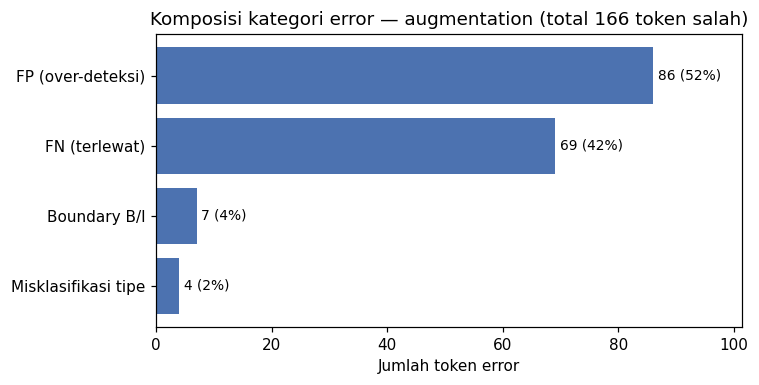

In [3]:
cat_counts = df.loc[df.is_error, 'category'].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#4C72B0')
for b, v in zip(bars, cat_counts.values[::-1]):
    ax.text(v + max(cat_counts.values)*0.01, b.get_y()+b.get_height()/2,
            f'{v} ({v/n_err*100:.0f}%)', va='center', fontsize=9)
ax.set_xlabel('Jumlah token error')
ax.set_title(f'Komposisi kategori error — {SELECTED} (total {n_err} token salah)')
ax.margins(x=0.18)
plt.tight_layout()
plt.savefig(OUT_DIR / f'error_kategori_{SELECTED}.png', bbox_inches='tight')
plt.show()

## 2. Kelas mana yang paling banyak salah?

- **FN per kelas** = token entitas gold yang gagal terdeteksi (jadi `O`).
- **FP per kelas** = token `O` gold yang malah diprediksi entitas (dihitung di kelas prediksinya).
- **error_rate** = FN / jumlah token gold kelas tsb (relatif ke ukuran kelas).

In [4]:
fn = df[df.category == 'FN (terlewat)'].groupby('gold_type').size()
fp = df[df.category == 'FP (over-deteksi)'].groupby('pred_type').size()
mis = df[df.category == 'Misklasifikasi tipe'].groupby('gold_type').size()
support = df[df.gold_type != 'O'].groupby('gold_type').size()

summary = pd.DataFrame({
    'support_gold': support, 'FN_terlewat': fn,
    'FP_overdeteksi': fp, 'misklasifikasi': mis,
}).reindex(LABELS).fillna(0).astype(int)
summary['error_rate_%'] = (summary['FN_terlewat'] / summary['support_gold'] * 100).round(1)
summary

,support_gold,FN_terlewat,FP_overdeteksi,misklasifikasi,error_rate_%
PERSON,2302,34,62,0,1.5
LOCATION,475,13,15,4,2.7
EVENT,108,8,1,0,7.4
TIME,232,14,8,0,6.0


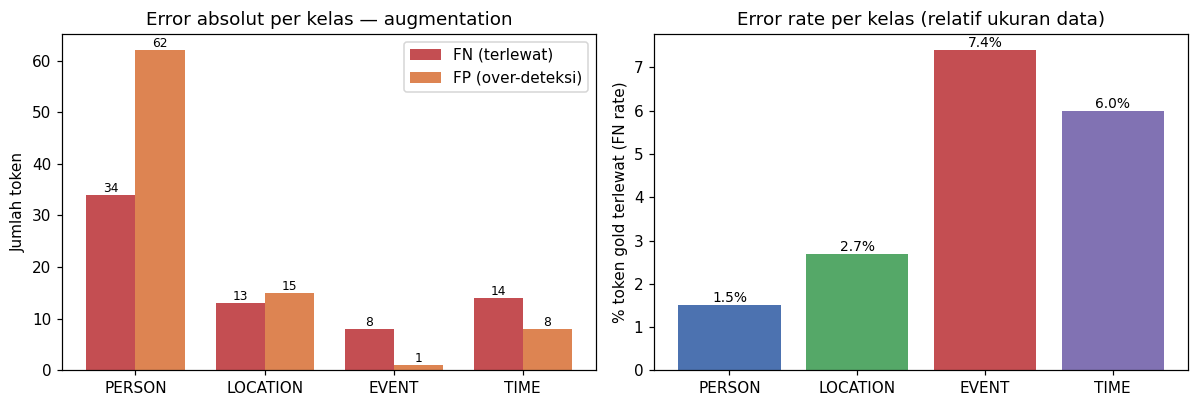

Kelas minoritas (EVENT, TIME) cenderung error-rate lebih tinggi -> efek few-shot.


In [5]:
x = np.arange(len(LABELS)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(x - w/2, summary['FN_terlewat'], w, label='FN (terlewat)', color='#C44E52')
axes[0].bar(x + w/2, summary['FP_overdeteksi'], w, label='FP (over-deteksi)', color='#DD8452')
axes[0].set_xticks(x); axes[0].set_xticklabels(LABELS); axes[0].set_ylabel('Jumlah token')
axes[0].set_title(f'Error absolut per kelas — {SELECTED}'); axes[0].legend()
for i, (a, b) in enumerate(zip(summary['FN_terlewat'], summary['FP_overdeteksi'])):
    axes[0].text(i - w/2, a, str(a), ha='center', va='bottom', fontsize=8)
    axes[0].text(i + w/2, b, str(b), ha='center', va='bottom', fontsize=8)
bars = axes[1].bar(x, summary['error_rate_%'], color=[COLORS[l] for l in LABELS])
axes[1].set_xticks(x); axes[1].set_xticklabels(LABELS)
axes[1].set_ylabel('% token gold terlewat (FN rate)')
axes[1].set_title('Error rate per kelas (relatif ukuran data)')
for b, v in zip(bars, summary['error_rate_%']):
    axes[1].text(b.get_x()+b.get_width()/2, v, f'{v}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / f'error_per_kelas_{SELECTED}.png', bbox_inches='tight')
plt.show()
print('Kelas minoritas (EVENT, TIME) cenderung error-rate lebih tinggi -> efek few-shot.')

## 3. Confusion matrix token-level (tipe)

Baris = gold, kolom = prediksi. Off-diagonal besar di baris/kolom `O` = masalah **deteksi**; off-diagonal antar-entitas = **salah tipe**.

pred_type,O,PERSON,LOCATION,EVENT,TIME
gold_type,,,,,
O,39355,62,15,1,8
PERSON,34,2268,0,0,0
LOCATION,13,2,458,2,0
EVENT,8,0,0,100,0
TIME,14,0,0,0,218


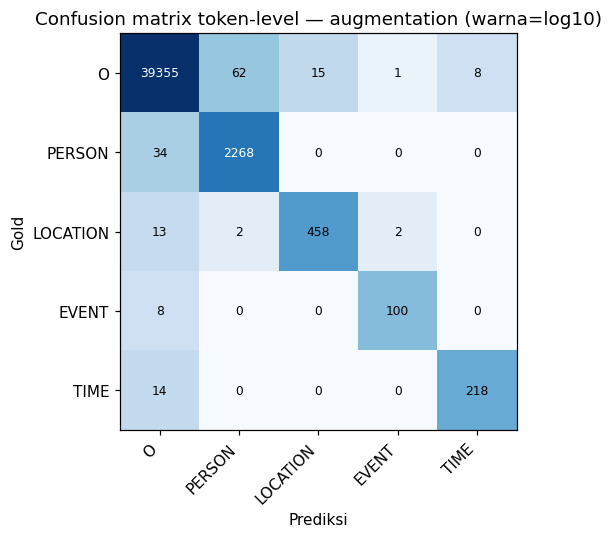

Error antar-entitas (bukan ke/dari O): 4  <- kecil = model paham 4 tipe, masalahnya deteksi


In [6]:
order = ['O'] + LABELS
cm = pd.crosstab(df.gold_type, df.pred_type).reindex(index=order, columns=order).fillna(0).astype(int)
display(cm)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.log10(cm.values + 1), cmap='Blues')
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Gold')
ax.set_title(f'Confusion matrix token-level — {SELECTED} (warna=log10)')
mx = np.log10(cm.values.max() + 1)
for i in range(len(order)):
    for j in range(len(order)):
        v = cm.values[i, j]
        ax.text(j, i, f'{v}', ha='center', va='center',
                color='white' if np.log10(v+1) > mx*0.6 else 'black', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_matrix_{SELECTED}.png', bbox_inches='tight')
plt.show()

ent2ent = cm.loc[LABELS, LABELS].values.sum() - np.trace(cm.loc[LABELS, LABELS].values)
print(f'Error antar-entitas (bukan ke/dari O): {ent2ent}  <- kecil = model paham 4 tipe, masalahnya deteksi')

## 4. Bukti asli: contoh kesalahan ber-highlight dalam konteks

Konteks diambil dari kolom `text` (teks chunk asli). Token salah di-highlight. Siap screenshot untuk Bab 4.

In [7]:
BADGE = {
    'FN (terlewat)': '#C44E52', 'FP (over-deteksi)': '#DD8452',
    'Misklasifikasi tipe': '#8172B3', 'Boundary B/I': '#937860',
}
_norm = lambda s: re.sub(r'[^0-9A-Za-z]', '', str(s)).lower()

def _context(token, text, window=8):
    """Cari `token` di dalam `text`, kembalikan window kata dengan token di-mark (indeks token)."""
    words = str(text).split()
    tn = _norm(token)
    pos = next((k for k, wd in enumerate(words) if _norm(wd) == tn), None)
    if pos is None:
        pos = next((k for k, wd in enumerate(words) if tn and tn in _norm(wd)), None)
    if pos is None:
        return None, None
    lo, hi = max(0, pos-window), min(len(words), pos+window+1)
    return words, (lo, pos, hi)

def show_examples(category, n=8, window=8, seed=0):
    err = df[df.category == category]
    if err.empty:
        display(HTML(f'<i>Tidak ada error kategori "{category}".</i>')); return
    sample = err.sample(min(n, len(err)), random_state=seed)
    color = BADGE.get(category, '#333')
    html = [f'<h4 style="margin:6px 0">{category} '
            f'<span style="font-weight:normal;color:#888">({len(err)} token, skenario {SELECTED})</span></h4>']
    for _, r in sample.iterrows():
        words, span = _context(r.token, r.text, window)
        if words is None:
            ctx = f'…{r.token}…'
        else:
            lo, pos, hi = span
            ctx = ' '.join(
                f'<mark style="background:{color};color:white;padding:1px 4px;border-radius:3px;font-weight:bold">{words[k]}</mark>'
                if k == pos else words[k] for k in range(lo, hi))
        html.append(
            f'<div style="margin:6px 0;padding:6px 10px;border-left:3px solid {color};'
            f'background:#fafafa;font-size:13px">…{ctx}…<br>'
            f'<span style="color:#666;font-size:11px">token=<b>{r.token}</b> &nbsp; '
            f'gold=<b>{r.gold}</b> &nbsp; pred=<b>{r.pred}</b> &nbsp; chunk={r.text_id}</span></div>')
    display(HTML('\n'.join(html)))

In [8]:
show_examples('FN (terlewat)', n=8)

In [9]:
show_examples('FP (over-deteksi)', n=8)

In [10]:
show_examples('Misklasifikasi tipe', n=8)
show_examples('Boundary B/I', n=6)

In [11]:
# Fokus FN per kelas minoritas (EVENT/TIME) — token yang paling sering terlewat
def show_fn_by_class(klass, n=6, window=8, seed=1):
    sub = df[(df.category == 'FN (terlewat)') & (df.gold_type == klass)]
    print(f'== FN {klass}: {len(sub)} token terlewat ==')
    if sub.empty:
        return
    color = COLORS[klass]
    html = []
    for _, r in sub.sample(min(n, len(sub)), random_state=seed).iterrows():
        words, span = _context(r.token, r.text, window)
        if words is None:
            ctx = f'…{r.token}…'
        else:
            lo, pos, hi = span
            ctx = ' '.join(
                f'<mark style="background:{color};color:white;padding:1px 4px;border-radius:3px">{words[k]}</mark>'
                if k == pos else words[k] for k in range(lo, hi))
        html.append(f'<div style="margin:5px 0;font-size:13px">• …{ctx}… '
                    f'<span style="color:#888;font-size:11px">({r.text_id})</span></div>')
    display(HTML('\n'.join(html)))

show_fn_by_class('EVENT', n=6)
show_fn_by_class('TIME', n=6)

== FN EVENT: 8 token terlewat ==

== FN TIME: 14 token terlewat ==


## 5. Perbandingan antar-skenario (semua run baru)

Untuk tiap skenario: total token error + komposisi FN per kelas. Memperlihatkan apakah kelas dominan-salah konsisten, dan anomali backbone tertentu (cased/roberta).

In [12]:
rows = []
for name, rel in SCENARIO_FILES.items():
    f = DONE_RUNNING / rel
    if not f.exists():
        print('SKIP:', name); continue
    x = pd.read_excel(f).rename(columns={'true_label': 'gold', 'pred_label': 'pred'})
    x['gold'] = x['gold'].fillna('O'); x['pred'] = x['pred'].fillna('O')
    x['g'] = x['gold'].map(etype); x['p'] = x['pred'].map(etype)
    x['cat'] = [error_category(a, b) for a, b in zip(x['gold'], x['pred'])]
    rec = {'skenario': name, 'total_error': len(x)}
    for k in LABELS:
        rec[f'FN_{k}'] = int(((x.cat == 'FN (terlewat)') & (x.g == k)).sum())
        rec[f'FP_{k}'] = int(((x.cat == 'FP (over-deteksi)') & (x.p == k)).sum())
    rows.append(rec)
comp = pd.DataFrame(rows).set_index('skenario') if rows else pd.DataFrame()
comp

,total_error,FN_PERSON,FP_PERSON,FN_LOCATION,FP_LOCATION,FN_EVENT,FP_EVENT,FN_TIME,FP_TIME
skenario,,,,,,,,,
augmentation,166,34,62,13,15,8,1,14,8
S1-baseline,192,45,53,23,14,11,2,12,17
S2-weightedCE,232,24,90,21,35,11,1,11,24
S2a-SCL,197,28,69,15,26,11,1,9,22
S2b-JSCL,212,34,72,19,30,10,1,12,17
POS-tag,224,25,87,17,30,10,1,10,28
cahya(uncased),243,35,96,24,19,11,3,12,26
distilbert,216,17,90,18,22,10,1,14,29
indobert-cased,721,172,239,40,20,19,8,31,55


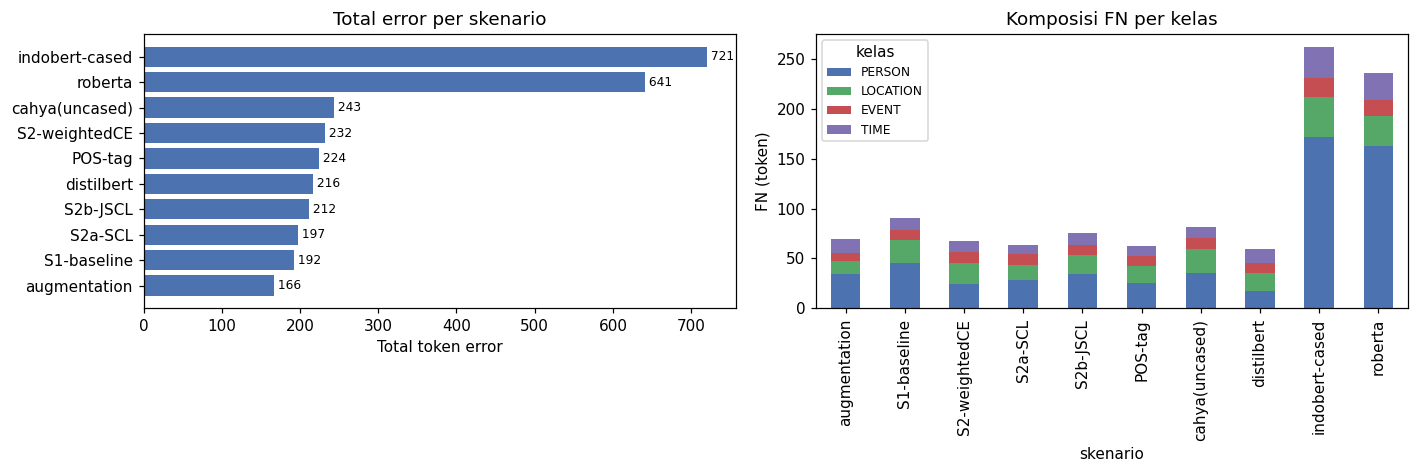

cased/roberta total error jauh lebih besar = anomali (lihat diagnose_grupb_anomaly.md);
uncased (cahya/distilbert) & augmentation paling rendah.


In [13]:
if comp.empty:
    print('comp kosong.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    comp_sorted = comp.sort_values('total_error')
    axes[0].barh(comp_sorted.index, comp_sorted['total_error'], color='#4C72B0')
    for i, v in enumerate(comp_sorted['total_error']):
        axes[0].text(v, i, f' {v}', va='center', fontsize=8)
    axes[0].set_xlabel('Total token error'); axes[0].set_title('Total error per skenario')
    fn_cols = [f'FN_{k}' for k in LABELS]
    comp[fn_cols].plot(kind='bar', stacked=True, ax=axes[1], color=[COLORS[k] for k in LABELS])
    axes[1].set_ylabel('FN (token)'); axes[1].set_title('Komposisi FN per kelas')
    axes[1].legend(LABELS, title='kelas', fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'perbandingan_antar_skenario.png', bbox_inches='tight')
    plt.show()
    print('cased/roberta total error jauh lebih besar = anomali (lihat diagnose_grupb_anomaly.md);')
    print('uncased (cahya/distilbert) & augmentation paling rendah.')

## 6. Ringkasan (otomatis)

In [14]:
fn_t = int((df.category == 'FN (terlewat)').sum())
fp_t = int((df.category == 'FP (over-deteksi)').sum())
mis_t = int((df.category == 'Misklasifikasi tipe').sum())
print(f'Skenario: {SELECTED}  (run baru done_running)')
print(f'Total token salah        : {n_err} dari {n_tok} ({n_err/n_tok*100:.2f}%)')
print(f'  - FN (terlewat)        : {fn_t} ({fn_t/n_err*100:.0f}%)')
print(f'  - FP (over-deteksi)    : {fp_t} ({fp_t/n_err*100:.0f}%)')
print(f'  - Misklasifikasi tipe  : {mis_t} ({mis_t/n_err*100:.0f}%)  <- kecil = bukan masalah tipe')
print(f'Kelas FN absolut terbanyak : {summary["FN_terlewat"].idxmax()}')
print(f'Kelas error-rate tertinggi : {summary["error_rate_%"].idxmax()} ({summary["error_rate_%"].max()}%)')
print('\nGambar tersimpan di:', OUT_DIR)
for p in sorted(OUT_DIR.glob('*.png')):
    print('  -', p.name)

Skenario: augmentation  (run baru done_running)
Total token salah        : 166 dari 42558 (0.39%)
  - FN (terlewat)        : 69 (42%)
  - FP (over-deteksi)    : 86 (52%)
  - Misklasifikasi tipe  : 4 (2%)  <- kecil = bukan masalah tipe
Kelas FN absolut terbanyak : PERSON
Kelas error-rate tertinggi : EVENT (7.4%)

Gambar tersimpan di: E:\2_Kehidupan-Kuliah\10_tugas-akhir\repo-TA\TA_preprocess\TA_sirah\data\result\analysis\error_viz
  - confusion_matrix_augmentation.png
  - error_kategori_augmentation.png
  - error_per_kelas_augmentation.png
  - perbandingan_antar_skenario.png


## 7. Batch export semua skenario

Loop ke-10 skenario di `done_running/` lalu simpan PNG **confusion matrix** + **error per kelas** masing-masing ke `error_viz/per_skenario/<skenario>/`, plus satu CSV ringkasan error semua skenario. Jadi tiap skenario punya visualisasinya sendiri tanpa mengganti `SELECTED` manual.

In [15]:
def export_scenario(name, outdir):
    """Render & simpan confusion + error-per-kelas untuk satu skenario. Return dict ringkasan."""
    d = load_scenario(name)
    nt, ne = len(d), int(d.is_error.sum())
    fn = d[d.category == 'FN (terlewat)'].groupby('gold_type').size()
    fp = d[d.category == 'FP (over-deteksi)'].groupby('pred_type').size()
    sup = d[d.gold_type != 'O'].groupby('gold_type').size()
    s = pd.DataFrame({'support': sup, 'FN': fn, 'FP': fp}).reindex(LABELS).fillna(0).astype(int)
    s['FN_rate_%'] = (s['FN'] / s['support'] * 100).round(1)

    # 1) error per kelas
    x = np.arange(len(LABELS)); w = 0.38
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.bar(x - w/2, s['FN'], w, label='FN (terlewat)', color='#C44E52')
    ax.bar(x + w/2, s['FP'], w, label='FP (over-deteksi)', color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylabel('token')
    ax.set_title(f'{name}: error per kelas (total {ne})'); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(outdir / 'error_per_kelas.png', bbox_inches='tight'); plt.close(fig)

    # 2) confusion matrix
    order = ['O'] + LABELS
    cm = pd.crosstab(d.gold_type, d.pred_type).reindex(index=order, columns=order).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(5.5, 4.6))
    ax.imshow(np.log10(cm.values + 1), cmap='Blues')
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Gold'); ax.set_title(f'{name}: confusion (log10)')
    mx = np.log10(cm.values.max() + 1)
    for i in range(len(order)):
        for j in range(len(order)):
            v = cm.values[i, j]
            ax.text(j, i, f'{v}', ha='center', va='center',
                    color='white' if np.log10(v+1) > mx*0.6 else 'black', fontsize=7)
    fig.tight_layout(); fig.savefig(outdir / 'confusion_matrix.png', bbox_inches='tight'); plt.close(fig)

    rec = {'skenario': name, 'total_token': nt, 'total_error': ne, 'error_%': round(ne/nt*100, 3)}
    for k in LABELS:
        rec[f'FN_{k}'] = int(s.loc[k, 'FN']); rec[f'FP_{k}'] = int(s.loc[k, 'FP'])
        rec[f'FNrate_{k}_%'] = float(s.loc[k, 'FN_rate_%'])
    return rec


per_dir = OUT_DIR / 'per_skenario'
recs = []
for nm in SCENARIO_FILES:
    od = per_dir / nm.replace('(', '_').replace(')', '')
    od.mkdir(parents=True, exist_ok=True)
    try:
        recs.append(export_scenario(nm, od))
        print('OK  ', nm)
    except Exception as e:
        print('GAGAL', nm, '->', repr(e))

ringkasan = pd.DataFrame(recs).set_index('skenario').sort_values('total_error')
ringkasan.to_csv(OUT_DIR / 'ringkasan_error_semua_skenario.csv')
print('\nDisimpan:', per_dir, '+ ringkasan_error_semua_skenario.csv')
ringkasan[['total_error', 'error_%', 'FN_PERSON', 'FN_LOCATION', 'FN_EVENT', 'FN_TIME']]

OK   augmentation


OK   S1-baseline


OK   S2-weightedCE


OK   S2a-SCL


OK   S2b-JSCL


...

OK   cahya(uncased)


OK   distilbert


OK   indobert-cased


OK   roberta

Disimpan: E:\2_Kehidupan-Kuliah\10_tugas-akhir\repo-TA\TA_preprocess\TA_sirah\data\result\analysis\error_viz\per_skenario + ringkasan_error_semua_skenario.csv


,total_error,error_%,FN_PERSON,FN_LOCATION,FN_EVENT,FN_TIME
skenario,,,,,,
augmentation,166,0.390,34,13,8,14
S1-baseline,192,0.451,45,23,11,12
S2a-SCL,197,0.463,28,15,11,9
S2b-JSCL,212,0.498,34,19,10,12
distilbert,216,0.508,17,18,10,14
POS-tag,224,0.526,25,17,10,10
S2-weightedCE,232,0.545,24,21,11,11
cahya(uncased),243,0.571,35,24,11,12
roberta,641,1.506,163,30,16,27
